In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/raw/flights_2025_01.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

print(df.shape)
df.head()

(539747, 26)


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,...,CRS_DEP_TIME,DEP_TIME_BLK,CRS_ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,ARR_TIME_BLK,CANCELLED,DIVERTED,DISTANCE,DISTANCE_GROUP
0,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,AA,N101NN,164,...,1030,1000-1059,1912,0.0,0.0,1900-1959,0.0,0.0,2586.0,11
1,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,AA,N101NN,76,...,600,0600-0659,940,0.0,0.0,0900-0959,0.0,0.0,2586.0,11
2,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,AA,N102UW,3244,...,819,0800-0859,1206,0.0,0.0,1200-1259,0.0,0.0,1095.0,5
3,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,AA,N103NN,185,...,2100,2100-2159,29,0.0,0.0,0001-0559,0.0,0.0,2475.0,10
4,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,AA,N103NN,2455,...,801,0800-0859,1140,0.0,0.0,1100-1159,0.0,0.0,2611.0,11


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               539747 non-null  int64  
 1   QUARTER            539747 non-null  int64  
 2   MONTH              539747 non-null  int64  
 3   DAY_OF_MONTH       539747 non-null  int64  
 4   DAY_OF_WEEK        539747 non-null  int64  
 5   FL_DATE            539747 non-null  str    
 6   OP_UNIQUE_CARRIER  539747 non-null  str    
 7   OP_CARRIER         539747 non-null  str    
 8   TAIL_NUM           537217 non-null  str    
 9   OP_CARRIER_FL_NUM  539747 non-null  int64  
 10  ORIGIN             539747 non-null  str    
 11  ORIGIN_CITY_NAME   539747 non-null  str    
 12  ORIGIN_STATE_ABR   539747 non-null  str    
 13  DEST               539747 non-null  str    
 14  DEST_CITY_NAME     539747 non-null  str    
 15  DEST_STATE_ABR     539747 non-null  str    
 16  CRS_DEP_TIME 

In [3]:
df["ARR_DEL15"].value_counts(dropna=False)

ARR_DEL15
0.0    424139
1.0     98130
NaN     17478
Name: count, dtype: int64

In [4]:
missing_target = df[df["ARR_DEL15"].isna()]

missing_target[["CANCELLED", "DIVERTED"]].value_counts(dropna=False)

CANCELLED  DIVERTED
1.0        0.0         16312
0.0        1.0          1166
Name: count, dtype: int64

In [5]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(522269, 26)

In [6]:
completed["ARR_DEL15"].value_counts(normalize=True) * 100

ARR_DEL15
0.0    81.210832
1.0    18.789168
Name: proportion, dtype: float64

In [7]:
completed["ARR_DEL15"].value_counts()

ARR_DEL15
0.0    424139
1.0     98130
Name: count, dtype: int64

In [8]:
airline_delay = (
    completed
    .groupby("OP_UNIQUE_CARRIER")["ARR_DEL15"]
    .agg(["count","mean"])
    .sort_values("mean", ascending=False)
)

airline_delay["late_rate_percent"] = airline_delay["mean"] * 100
airline_delay

,count,mean,late_rate_percent
OP_UNIQUE_CARRIER,,,
F9,15110,0.259762,25.976175
OH,19151,0.254817,25.481698
B6,17558,0.244561,24.456088
G4,9206,0.237128,23.712796
OO,63502,0.208828,20.882807
DL,74025,0.193205,19.320500
AA,72082,0.192281,19.228101
MQ,20831,0.184293,18.429264
NK,16946,0.180810,18.080963


In [9]:
origin_delay = (
    completed
    .groupby("ORIGIN")["ARR_DEL15"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

origin_delay["late_rate_percent"] = origin_delay["mean"] * 100

origin_delay[origin_delay["count"] >= 500].head(20)

,count,mean,late_rate_percent
ORIGIN,,,
ASE,970,0.335052,33.505155
HSV,620,0.325806,32.580645
EGE,722,0.279778,27.977839
SYR,882,0.273243,27.324263
SFB,787,0.270648,27.064803
BZN,767,0.265971,26.597132
EYW,735,0.265306,26.530612
JAC,586,0.262799,26.279863
DAY,559,0.261181,26.118068


In [10]:
time_block_delay = (
    completed
    .groupby("DEP_TIME_BLK")["ARR_DEL15"]
    .agg(["count", "mean"])
)

time_block_delay["late_rate_percent"] = time_block_delay["mean"] * 100
time_block_delay.sort_index()

,count,mean,late_rate_percent
DEP_TIME_BLK,,,
0001-0559,14430,0.125502,12.550243
0600-0659,35230,0.125632,12.563156
0700-0759,36580,0.146665,14.666484
0800-0859,37650,0.155299,15.529880
0900-0959,31326,0.156515,15.651535
1000-1059,32059,0.173150,17.314951
1100-1159,34881,0.175511,17.551102
1200-1259,32004,0.189039,18.903887
1300-1359,31831,0.191103,19.110301


In [11]:
day_delay = (
    completed
    .groupby("DAY_OF_WEEK")["ARR_DEL15"]
    .agg(["count", "mean"])
)

day_delay["late_rate_percent"] = day_delay["mean"] * 100
day_delay

,count,mean,late_rate_percent
DAY_OF_WEEK,,,
1,70684,0.226388,22.638787
2,61458,0.153129,15.312897
3,79713,0.132801,13.280143
4,88859,0.173680,17.367965
5,88355,0.194624,19.462396
6,62165,0.216392,21.639186
7,71035,0.225945,22.594496


In [12]:
completed["ROUTE"] = completed["ORIGIN"] + "_" + completed["DEST"]

route_delay = (
    completed
    .groupby("ROUTE")["ARR_DEL15"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

route_delay["late_rate_percent"] = route_delay["mean"] * 100

route_delay[route_delay["count"] >= 100].head(20)

,count,mean,late_rate_percent
ROUTE,,,
ORD_ASE,139,0.453237,45.323741
HSV_DFW,161,0.447205,44.720497
DEN_MAF,117,0.427350,42.735043
BOS_PBI,236,0.419492,41.949153
DTW_MIA,141,0.397163,39.716312
EGE_DFW,121,0.388430,38.842975
DEN_BIS,124,0.387097,38.709677
BOS_IAH,109,0.385321,38.532110
ASE_ORD,138,0.384058,38.405797


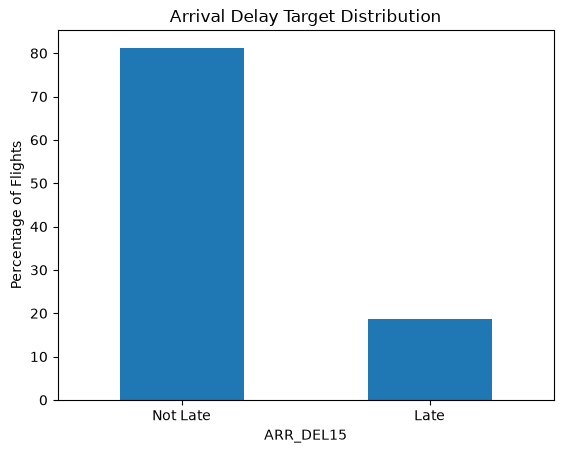

In [13]:
late_rate = completed["ARR_DEL15"].value_counts(normalize=True).sort_index() * 100

late_rate.plot(kind="bar")
plt.title("Arrival Delay Target Distribution")
plt.xlabel("ARR_DEL15")
plt.ylabel("Percentage of Flights")
plt.xticks([0, 1], ["Not Late", "Late"], rotation=0)
plt.show()